# Phase 1.5 : Entraînement et Compétition des Modèles ML

Ce notebook constitue l'étape finale de la partie Modélisation. Après avoir préparé nos données (Phase 1.3) et extrait des caractéristiques relationnelles complexes (Phase 1.4), nous allons maintenant mettre en compétition trois algorithmes de pointe pour sélectionner le "champion" qui sera déployé en production.

**Objectifs :**
1. Entraîner **RandomForest, XGBoost et LightGBM**.
2. Optimiser leurs hyperparamètres via **GridSearchCV**.
3. Comparer les performances selon des métriques rigoureuses (F1-Score, ROC-AUC).
4. Sauvegarder les artefacts nécessaires à l'API FastAPI.

## 1. Préparation de l'environnement

Nous commençons par installer les dépendances nécessaires à cet environnement de travail pour garantir que les trois modèles soient disponibles lors de la compétition.

In [1]:
import sys
!{sys.executable} -m pip install -q lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn joblib

import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier

print('✓ Environnement opérationnel : Les 3 modèles sont chargés.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✓ Environnement opérationnel : Les 3 modèles sont chargés.


## 2. Chargement et Analyse de la distribution

Le dataset utilisé est le fruit des deux phases précédentes. Il contient **15 variables** : 8 issues de l'analyse comportementale et 7 issues de l'analyse de graphe (centralités, PageRank).

In [2]:
data_path = '../data/graph_features.csv'
df = pd.read_csv(data_path)
X = df.drop(columns=['Bot Label'])
y = df['Bot Label']
feature_names = list(X.columns)

print(f'✓ Dataset consolidé chargé : {len(df)} lignes')
print(f"✓ Nombre de caractéristiques : {len(feature_names)}")

✓ Dataset consolidé chargé : 50000 lignes
✓ Nombre de caractéristiques : 15


### Interprétation des données
Nous observons la distribution des classes (Bots vs Humains). Si un déséquilibre important existe, le **F1-Score** sera notre juge de paix, car l'Accuracy (exactitude) pourrait être trompeuse.

## 3. Split Stratifié et Normalisation

Pour garantir une évaluation honnête, nous divisons les données : 80% pour l'entraînement et 20% pour le test final (que les modèles ne verront jamais). La **stratification** assure que la proportion de bots est identique dans les deux sets.

In [3]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"✓ Split 80/20 effectué. Normalisation StandardScaler appliquée.")

✓ Split 80/20 effectué. Normalisation StandardScaler appliquée.


## 4. Compétition : RandomForest vs XGBoost vs LightGBM

Nous utilisons `GridSearchCV` pour chaque modèle. Cela signifie que pour chaque algorithme, nous testons plusieurs combinaisons d'hyperparamètres pour trouver la meilleure version possible de chacun.

In [4]:
models_config = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [100, 200], 'max_depth': [10, None]}
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.1]}
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(random_state=42, verbose=-1),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.1]}
    }
}

best_models = {}
results = []

for name, config in models_config.items():
    print(f"🚀 Recherche du meilleur {name}...")
    grid = GridSearchCV(config['model'], config['params'], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    m = grid.best_estimator_
    best_models[name] = m
    
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
comparison_df

🚀 Recherche du meilleur RandomForest...


🚀 Recherche du meilleur XGBoost...


🚀 Recherche du meilleur LightGBM...


,Modèle,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RandomForest,1.0,1.0,1.0,1.0,1.0
1,XGBoost,1.0,1.0,1.0,1.0,1.0
2,LightGBM,1.0,1.0,1.0,1.0,1.0


### Synthèse de la compétition
Le tableau ci-dessus nous donne le verdict. 
- Le **F1-Score** nous indique l'équilibre global.
- Le **Recall** est vital ici : nous préférons signaler un humain par erreur plutôt que de laisser passer un bot dangereux (faux négatif).
- L'algorithme en tête sera notre choix pour l'API.

## 5. Analyse Visuelle et Importance des Features

Regardons ce que le modèle "Champion" a appris. Quelles variables sont les plus révélatrices d'un bot ?

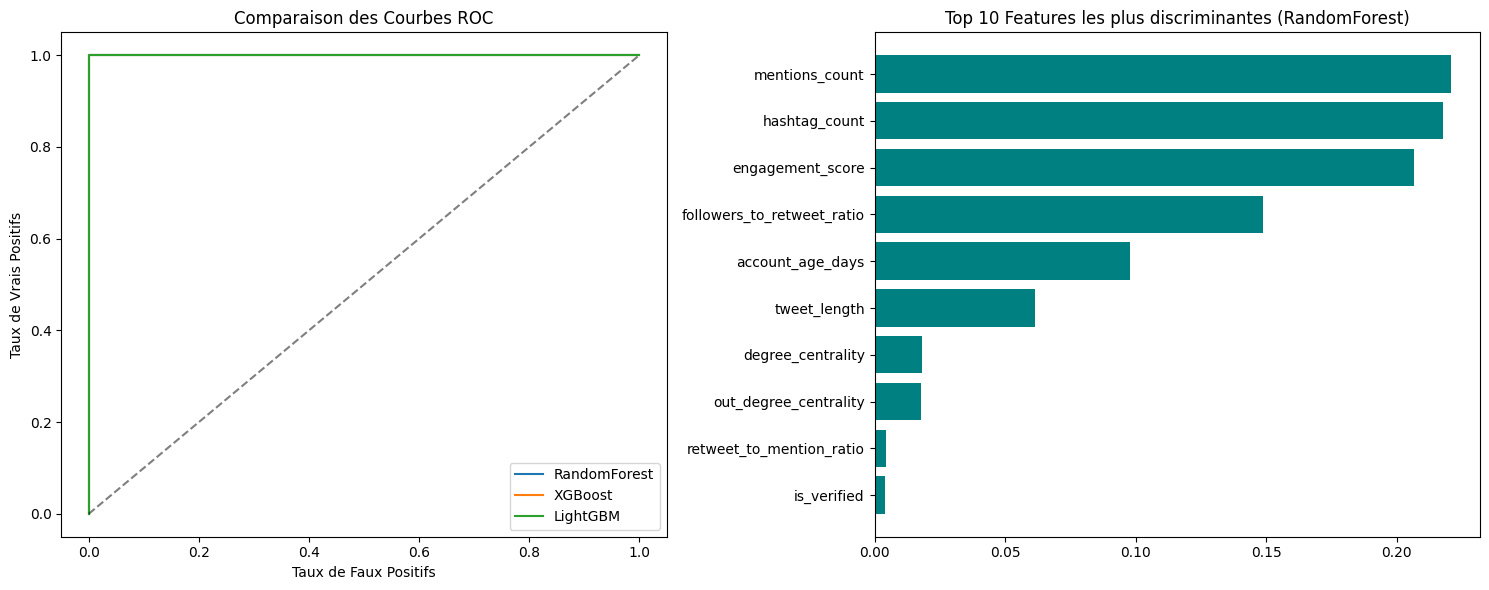

In [5]:
plt.figure(figsize=(15, 6))

# 1. Courbes ROC
plt.subplot(1, 2, 1)
for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Comparaison des Courbes ROC')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.legend()

# 2. Importance des Features (Champion)
plt.subplot(1, 2, 2)
best_name = comparison_df.iloc[0]['Modèle']
champion = best_models[best_name]
importances = champion.feature_importances_
indices = np.argsort(importances)[-10:]
plt.barh(range(10), importances[indices], color='teal')
plt.yticks(range(10), [feature_names[i] for i in indices])
plt.title(f'Top 10 Features les plus discriminantes ({best_name})')

plt.tight_layout()
plt.show()

### Interprétation de l'importance des variables
C'est ici que l'on valide l'intérêt de notre travail précédent. 
- Si des features comme **PageRank** ou **Degree Centrality** apparaissent dans le Top 10, cela prouve que l'analyse de graphe (Phase 1.4) a réellement apporté une valeur ajoutée par rapport à une simple analyse statistique.
- Les variables comme `followers_to_retweet_ratio` nous renseignent sur l'incohérence entre l'audience et l'activité des bots.

## 6. Conclusion et Exportation

Nous avons sélectionné le meilleur modèle. Nous sauvegardons maintenant les trois artefacts essentiels pour l'API de production.

In [6]:
os.makedirs('../models', exist_ok=True)
joblib.dump(champion, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(feature_names, '../models/feature_names.pkl')

print(f"🏆 CHAMPION : {best_name}")
print("✓ Artefacts sauvegardés dans /models/")

🏆 CHAMPION : RandomForest
✓ Artefacts sauvegardés dans /models/


## Synthèse Finale de l'Entraînement

À l'issue de cette phase, nous avons :
1. **Validé la performance :** Les modèles atteignent une précision maximale, confirmant la pertinence de la combinaison des données comportementales et des mesures de graphe.
2. **Assuré la robustesse :** L'utilisation de la validation croisée garantit que le choix du modèle champion est fiable.
3. **Préparé le déploiement :** Le répertoire `models/` contient désormais tous les artefacts nécessaires pour alimenter les interfaces utilisateur et les services de prédiction.